In [66]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats.mstats import winsorize
import warnings
warnings.filterwarnings('ignore')

# Configure visualizations
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print("*"*80)
print("FinMark Customer Segmentation")
print("*"*80)
print("✓ Success! Move on to the next line!\n")

********************************************************************************
FinMark Customer Segmentation
********************************************************************************
✓ Success! Move on to the next line!



In [67]:
print("STEP 1.1: LOADING RAW DATASETS")
print("*"*80)

# Load raw datasets
transactions_df = pd.read_csv('C:\\Users\\USER\\Downloads\\Transaction_Data.csv')
feedback_df = pd.read_csv('C:\\Users\\USER\\Downloads\\Customer_Feedback_Data.csv')
products_df = pd.read_csv('C:\\Users\\USER\\Downloads\\Product_Offering_Data.csv')

print(f"\n✓ Successfully loaded the ff Datasets:")
print(f"  • Transaction_Data.csv: {transactions_df.shape[0]:,} transactions, {transactions_df.shape[1]} columns")
print(f"  • Customer_Feedback_Data.csv: {feedback_df.shape[0]:,} feedback records, {feedback_df.shape[1]} columns")
print(f"  • Product_Offering_Data.csv: {products_df.shape[0]} products, {products_df.shape[1]} columns")

print(f"\nTransaction Data - First 3 rows:")
display(transactions_df.head(3))

print(f"\nCustomer Feedback Data - First 3 rows:")
display(feedback_df.head(3))

print(f"\nProduct Offering Data - First 3 rows:")
display(products_df.head(3))

STEP 1.1: LOADING RAW DATASETS
********************************************************************************

✓ Successfully loaded the ff Datasets:
  • Transaction_Data.csv: 5,050 transactions, 5 columns
  • Customer_Feedback_Data.csv: 5,050 feedback records, 4 columns
  • Product_Offering_Data.csv: 15 products, 6 columns

Transaction Data - First 3 rows:


,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Transaction_Type
0,1,393,2023-01-01 0:00:00,3472.0,Purchase
1,2,826,2023-01-01 1:00:00,NaN,Bill Payment
2,3,916,2023-01-01 2:00:00,10.0,Purchase



Customer Feedback Data - First 3 rows:


,Customer_ID,Satisfaction_Score,Feedback_Comments,Likelihood_to_Recommend
0,1,10.0,Very satisfied,9
1,2,3.0,Very satisfied,3
2,3,10.0,Very satisfied,1



Product Offering Data - First 3 rows:


,Product_ID,Product_Name,Product_Type,Risk_Level,Target_Age_Group,Target_Income_Group
0,1,Platinum Credit Card,Credit Card,Medium,NaN,Medium
1,2,Gold Savings Account,Savings Account,Low,NaN,Low
2,3,High-Yield Investment Account,Investment,High,NaN,High


In [68]:
print("\nSTEP 1.2: MERGING DATASETS (In correct order this time!)")
print("*"*80)

# Merge Transaction + Customer Feedback on Customer_ID
# This is BEFORE any cleaning - addressing sir edmon's feedback
merged_df = pd.merge(
    transactions_df,
    feedback_df,
    on='Customer_ID',
    how='inner'
)

print(f"\n✓ Merge completed!:")
print(f"  • Original transaction records: {len(transactions_df):,}")
print(f"  • Original feedback records: {len(feedback_df):,}")
print(f"  • Merged records: {len(merged_df):,}")
print(f"  • Unique customers: {merged_df['Customer_ID'].nunique():,}")
print(f"  • Merge type: INNER JOIN on Customer_ID")

print(f"\nMerged columns: {merged_df.columns.tolist()}")
print(f"\nMerged data - First 3 rows:")
display(merged_df.head(3))


STEP 1.2: MERGING DATASETS (In correct order this time!)
********************************************************************************

✓ Merge completed!:
  • Original transaction records: 5,050
  • Original feedback records: 5,050
  • Merged records: 25,623
  • Unique customers: 993
  • Merge type: INNER JOIN on Customer_ID

Merged columns: ['Transaction_ID', 'Customer_ID', 'Transaction_Date', 'Transaction_Amount', 'Transaction_Type', 'Satisfaction_Score', 'Feedback_Comments', 'Likelihood_to_Recommend']

Merged data - First 3 rows:


,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Transaction_Type,Satisfaction_Score,Feedback_Comments,Likelihood_to_Recommend
0,1,393,2023-01-01 0:00:00,3472.0,Purchase,1.0,Excellent,3
1,2,826,2023-01-01 1:00:00,NaN,Bill Payment,NaN,Needs improvement,3
2,2,826,2023-01-01 1:00:00,NaN,Bill Payment,10.0,Good service,5


In [69]:
print("\nSTEP 2.1: DATA QUALITY ASSESSMENT")
print("*"*80)

df = merged_df.copy()

# Missing values
print("\n1. MISSING VALUES ANALYSIS:")
missing_summary = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': df.isnull().sum().values,
    'Missing_%': (df.isnull().sum().values / len(df) * 100).round(2)
})
print(missing_summary[missing_summary['Missing_Count'] > 0].to_string(index=False))
print(f"Total missing: {df.isnull().sum().sum()}")

# Duplicates
print("\n2. DUPLICATES ANALYSIS:")
print(f"Total duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate Transaction_IDs: {df['Transaction_ID'].duplicated().sum()}")

# Data types
print("\n3. DATA TYPES:")
print(df.dtypes)


STEP 2.1: DATA QUALITY ASSESSMENT
********************************************************************************

1. MISSING VALUES ANALYSIS:
            Column  Missing_Count  Missing_%
Transaction_Amount            472       1.84
Satisfaction_Score            535       2.09
Total missing: 1007

2. DUPLICATES ANALYSIS:
Total duplicate rows: 657
Duplicate Transaction_IDs: 20623

3. DATA TYPES:
Transaction_ID               int64
Customer_ID                  int64
Transaction_Date            object
Transaction_Amount         float64
Transaction_Type            object
Satisfaction_Score         float64
Feedback_Comments           object
Likelihood_to_Recommend      int64
dtype: object


In [70]:
print("\nSTEP 2.2: HANDLING MISSING VALUES")
print("*"*80)

print("\nStrategy: MEDIAN IMPUTATION for numeric columns")
print("Rationale: Median is perfect for outliers and preserves distribution")

# Impute Transaction_Amount
if df['Transaction_Amount'].isnull().sum() > 0:
    missing_count = df['Transaction_Amount'].isnull().sum()
    median_val = df['Transaction_Amount'].median()
    df['Transaction_Amount'].fillna(median_val, inplace=True)
    print(f"\n✓ Transaction_Amount: Imputed {missing_count} values with median (${median_val:.2f})")

# Impute Satisfaction_Score
if df['Satisfaction_Score'].isnull().sum() > 0:
    missing_count = df['Satisfaction_Score'].isnull().sum()
    median_val = df['Satisfaction_Score'].median()
    df['Satisfaction_Score'].fillna(median_val, inplace=True)
    print(f"✓ Satisfaction_Score: Imputed {missing_count} values with median ({median_val:.1f})")

print(f"\nVerification: Missing values after imputation = {df.isnull().sum().sum()}")


STEP 2.2: HANDLING MISSING VALUES
********************************************************************************

Strategy: MEDIAN IMPUTATION for numeric columns
Rationale: Median is perfect for outliers and preserves distribution

✓ Transaction_Amount: Imputed 472 values with median ($2460.00)
✓ Satisfaction_Score: Imputed 535 values with median (6.0)

Verification: Missing values after imputation = 0


In [71]:
print("\nSTEP 2.3: REMOVING DUPLICATES")
print("*"*80)

rows_before = len(df)
df = df.drop_duplicates(subset=['Transaction_ID'], keep='first')
rows_removed = rows_before - len(df)

print(f"\n✓ Duplicate Removal:")
print(f"  • Rows before: {rows_before:,}")
print(f"  • Rows removed: {rows_removed:,}")
print(f"  • Rows after: {len(df):,}")
print(f"  • Method: Dropped duplicates based on Transaction_ID (kept first occurrence)")

print(f"\nVerification: Duplicate rows remaining = {df.duplicated().sum()}")


STEP 2.3: REMOVING DUPLICATES
********************************************************************************

✓ Duplicate Removal:
  • Rows before: 25,623
  • Rows removed: 20,623
  • Rows after: 5,000
  • Method: Dropped duplicates based on Transaction_ID (kept first occurrence)

Verification: Duplicate rows remaining = 0


In [72]:
print("\nSTEP 2.4: OUTLIER DETECTION & HANDLING")
print("*"*80)

# Satisfaction Score validation
print("\n1. SATISFACTION SCORE VALIDATION:")
print(f"   Valid range: 1-10")
print(f"   Range before: {df['Satisfaction_Score'].min()} to {df['Satisfaction_Score'].max()}")

outliers_above = (df['Satisfaction_Score'] > 10).sum()
outliers_below = (df['Satisfaction_Score'] < 1).sum()
print(f"   Values > 10: {outliers_above}, Values < 1: {outliers_below}")

df['Satisfaction_Score'] = df['Satisfaction_Score'].clip(lower=1, upper=10)
print(f"   Range after capping: {df['Satisfaction_Score'].min()} to {df['Satisfaction_Score'].max()}")
print(f"   ✓ Capped to valid range!")

# Transaction Amount (IQR method)
print("\n2. TRANSACTION AMOUNT OUTLIER DETECTION (IQR Method):")

Q1 = df['Transaction_Amount'].quantile(0.25)
Q3 = df['Transaction_Amount'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers_count = ((df['Transaction_Amount'] < lower_bound) | 
                  (df['Transaction_Amount'] > upper_bound)).sum()

print(f"   Q1: ${Q1:.2f}, Q3: ${Q3:.2f}, IQR: ${IQR:.2f}")
print(f"   Lower bound: ${lower_bound:.2f}, Upper bound: ${upper_bound:.2f}")
print(f"   Outliers detected: {outliers_count}")
print(f"   Range before: ${df['Transaction_Amount'].min():.2f} to ${df['Transaction_Amount'].max():.2f}")

df['Transaction_Amount'] = df['Transaction_Amount'].clip(lower=max(0, lower_bound), upper=upper_bound)
print(f"   Range after capping: ${df['Transaction_Amount'].min():.2f} to ${df['Transaction_Amount'].max():.2f}")
print(f"   ✓ Outliers capped to bounds")

# Categorical standardization
print("\n3. CATEGORICAL STANDARDIZATION:")
df['Transaction_Type'] = df['Transaction_Type'].str.strip().str.title()
df['Feedback_Comments'] = df['Feedback_Comments'].str.strip().str.title()
print(f"   ✓ Transaction_Type values: {sorted(df['Transaction_Type'].unique().tolist())}")
print(f"   ✓ Feedback_Comments values: {sorted(df['Feedback_Comments'].unique().tolist())}")

# Date conversion
print("\n4. DATE CONVERSION:")
df['Transaction_Date'] = pd.to_datetime(df['Transaction_Date'])
print(f"   ✓ Transaction_Date converted to datetime")
print(f"   Date range: {df['Transaction_Date'].min()} to {df['Transaction_Date'].max()}")


STEP 2.4: OUTLIER DETECTION & HANDLING
********************************************************************************

1. SATISFACTION SCORE VALIDATION:
   Valid range: 1-10
   Range before: 1.0 to 60.0
   Values > 10: 18, Values < 1: 0
   Range after capping: 1.0 to 10.0
   ✓ Capped to valid range!

2. TRANSACTION AMOUNT OUTLIER DETECTION (IQR Method):
   Q1: $1260.00, Q3: $3682.00, IQR: $2422.00
   Lower bound: $-2373.00, Upper bound: $7315.00
   Outliers detected: 10
   Range before: $10.00 to $480300.00
   Range after capping: $10.00 to $7315.00
   ✓ Outliers capped to bounds

3. CATEGORICAL STANDARDIZATION:
   ✓ Transaction_Type values: ['Bill Payment', 'Investment', 'Loan Payment', 'Purchase']
   ✓ Feedback_Comments values: ['Excellent', 'Good Service', 'Needs Improvement', 'Unsatisfactory', 'Very Satisfied']

4. DATE CONVERSION:
   ✓ Transaction_Date converted to datetime
   Date range: 2023-01-01 00:00:00 to 2023-07-28 07:00:00


In [73]:
print("\nSTEP 2.4.1: SATISFACTION SCORE WINSORIZATION")
print("*"*80)

print("\nApplying winsorization to Satisfaction_Score (caps extreme values at 5th/95th percentiles)")
print("Rationale: Reduces impact of outliers while preserving overall distribution")

# Check distribution before winsorization
print(f"\nBefore winsorization:")
print(f"  Mean: {df['Satisfaction_Score'].mean():.2f}")
print(f"  Std: {df['Satisfaction_Score'].std():.2f}")
print(f"  5th percentile: {df['Satisfaction_Score'].quantile(0.05):.2f}")
print(f"  95th percentile: {df['Satisfaction_Score'].quantile(0.95):.2f}")

# Apply winsorization (5% from each tail)
df['Satisfaction_Score'] = winsorize(df['Satisfaction_Score'], limits=[0.05, 0.05])

print(f"\nAfter winsorization:")
print(f"  Mean: {df['Satisfaction_Score'].mean():.2f}")
print(f"  Std: {df['Satisfaction_Score'].std():.2f}")
print(f"  Min: {df['Satisfaction_Score'].min():.2f}")
print(f"  Max: {df['Satisfaction_Score'].max():.2f}")
print("\n✓ Winsorization complete - outliers capped, distribution preserved")


STEP 2.4.1: SATISFACTION SCORE WINSORIZATION
********************************************************************************

Applying winsorization to Satisfaction_Score (caps extreme values at 5th/95th percentiles)
Rationale: Reduces impact of outliers while preserving overall distribution

Before winsorization:
  Mean: 5.56
  Std: 2.78
  5th percentile: 1.00
  95th percentile: 10.00

After winsorization:
  Mean: 5.56
  Std: 2.78
  Min: 1.00
  Max: 10.00

✓ Winsorization complete - outliers capped, distribution preserved


In [74]:
print("\nSTEP 2.5: DATA CLEANING SUMMARY")
print("*"*80)

print(f"\n✓ Cleaned dataset:")
print(f"  • Shape: {df.shape[0]:,} records × {df.shape[1]} columns")
print(f"  • Missing values: {df.isnull().sum().sum()}")
print(f"  • Duplicate rows: {df.duplicated().sum()}")
print(f"  • Data quality: READY FOR FEATURE ENGINEERING! WOOOHOOOO")

print(f"\nCleaned data sample:")
display(df.head())


STEP 2.5: DATA CLEANING SUMMARY
********************************************************************************

✓ Cleaned dataset:
  • Shape: 5,000 records × 8 columns
  • Missing values: 0
  • Duplicate rows: 0
  • Data quality: READY FOR FEATURE ENGINEERING! WOOOHOOOO

Cleaned data sample:


,Transaction_ID,Customer_ID,Transaction_Date,Transaction_Amount,Transaction_Type,Satisfaction_Score,Feedback_Comments,Likelihood_to_Recommend
0,1,393,2023-01-01 00:00:00,3472.0,Purchase,1.0,Excellent,3
1,2,826,2023-01-01 01:00:00,2460.0,Bill Payment,6.0,Needs Improvement,3
7,3,916,2023-01-01 02:00:00,10.0,Purchase,6.0,Needs Improvement,3
14,4,109,2023-01-01 03:00:00,72.0,Investment,3.0,Good Service,9
17,5,889,2023-01-01 04:00:00,1793.0,Investment,8.0,Very Satisfied,3


In [75]:
print("\nSTEP 3.1: INCOME GROUP DERIVATION (QUARTILE-BASED)")
print("*"*80)

print("\nMethodology:")
print("  • Data source: Transaction_Amount (all transactions)")
print("  • Method: Quartile boundaries (Q1=25%, Q3=75%)")
print("  • Rationale: Divides customers into distinct income tiers based on spending")
print("  • Groups:")
print("    - Low: Amount ≤ Q1 (bottom 25%)")
print("    - Medium: Q1 < Amount ≤ Q3 (middle 50%)")
print("    - High: Amount > Q3 (top 25%)")

# Calculate quartiles
Q1_income = df['Transaction_Amount'].quantile(0.25)
Q2_income = df['Transaction_Amount'].quantile(0.50)
Q3_income = df['Transaction_Amount'].quantile(0.75)

print(f"\nTransaction Amount Quartiles:")
print(f"  • Q1 (25th percentile): ${Q1_income:.2f}")
print(f"  • Q2 (50th percentile/Median): ${Q2_income:.2f}")
print(f"  • Q3 (75th percentile): ${Q3_income:.2f}")

# Assign income groups
def assign_income_group(amount):
    if amount <= Q1_income:
        return 'Low'
    elif amount <= Q3_income:
        return 'Medium'
    else:
        return 'High'

df['Income_Group'] = df['Transaction_Amount'].apply(assign_income_group)

print(f"\n✓ Income groups assigned to all transactions")
print(f"\nIncome Group Distribution:")
income_dist = df['Income_Group'].value_counts().sort_index()
for group in ['Low', 'Medium', 'High']:
    count = income_dist.get(group, 0)
    pct = count / len(df) * 100
    print(f"  • {group:8s}: {count:,} transactions ({pct:5.1f}%)")

# Validate
print(f"\nIncome Group Validation (Statistics):")
income_stats = df.groupby('Income_Group')['Transaction_Amount'].agg([
    ('Count', 'count'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Mean', 'mean'),
    ('Std', 'std')
]).round(2)
display(income_stats)

print("\n✓ Income groups correctly derived from transaction amount quartiles! On to the next step!")


STEP 3.1: INCOME GROUP DERIVATION (QUARTILE-BASED)
********************************************************************************

Methodology:
  • Data source: Transaction_Amount (all transactions)
  • Method: Quartile boundaries (Q1=25%, Q3=75%)
  • Rationale: Divides customers into distinct income tiers based on spending
  • Groups:
    - Low: Amount ≤ Q1 (bottom 25%)
    - Medium: Q1 < Amount ≤ Q3 (middle 50%)
    - High: Amount > Q3 (top 25%)

Transaction Amount Quartiles:
  • Q1 (25th percentile): $1260.00
  • Q2 (50th percentile/Median): $2460.00
  • Q3 (75th percentile): $3682.00

✓ Income groups assigned to all transactions

Income Group Distribution:
  • Low     : 1,251 transactions ( 25.0%)
  • Medium  : 2,501 transactions ( 50.0%)
  • High    : 1,248 transactions ( 25.0%)

Income Group Validation (Statistics):


,Count,Min,Max,Mean,Std
Income_Group,,,,,
High,1248,3684.0,7315.0,4384.72,462.09
Low,1251,10.0,1260.0,648.29,364.13
Medium,2501,1261.0,3682.0,2477.55,692.57



✓ Income groups correctly derived from transaction amount quartiles! On to the next step!


In [76]:
print("\nSTEP 4.1: TEMPORAL FEATURE EXTRACTION")
print("*"*80)

# Extract temporal components
df['Day_of_Week'] = df['Transaction_Date'].dt.day_name()
df['Hour_of_Day'] = df['Transaction_Date'].dt.hour
df['Month'] = df['Transaction_Date'].dt.month
df['Week_of_Year'] = df['Transaction_Date'].dt.isocalendar().week

# Create binary temporal features
df['Is_Business_Hours'] = ((df['Hour_of_Day'] >= 9) & (df['Hour_of_Day'] < 17)).astype(int)
df['Is_Weekend'] = (df['Day_of_Week'].isin(['Saturday', 'Sunday'])).astype(int)
df['Is_Morning'] = ((df['Hour_of_Day'] >= 6) & (df['Hour_of_Day'] < 12)).astype(int)
df['Is_Evening'] = ((df['Hour_of_Day'] >= 18) & (df['Hour_of_Day'] < 24)).astype(int)

print("\n✓ Temporal features created:")
print("  • Day_of_Week: Day name (Monday, Tuesday, etc.)")
print("  • Hour_of_Day: Hour of transaction (0-23)")
print("  • Month: Month of transaction (1-12)")
print("  • Week_of_Year: ISO week number")
print("  • Is_Business_Hours: Binary (1 = 9AM-5PM, 0 = outside)")
print("  • Is_Weekend: Binary (1 = Sat/Sun, 0 = weekday)")
print("  • Is_Morning: Binary (1 = 6AM-12PM, 0 = outside)")
print("  • Is_Evening: Binary (1 = 6PM-12AM, 0 = outside)")

print(f"\nTemporal features sample:")
display(df[['Transaction_Date', 'Day_of_Week', 'Hour_of_Day', 'Is_Business_Hours', 'Is_Weekend']].head(10))


STEP 4.1: TEMPORAL FEATURE EXTRACTION
********************************************************************************

✓ Temporal features created:
  • Day_of_Week: Day name (Monday, Tuesday, etc.)
  • Hour_of_Day: Hour of transaction (0-23)
  • Month: Month of transaction (1-12)
  • Week_of_Year: ISO week number
  • Is_Business_Hours: Binary (1 = 9AM-5PM, 0 = outside)
  • Is_Weekend: Binary (1 = Sat/Sun, 0 = weekday)
  • Is_Morning: Binary (1 = 6AM-12PM, 0 = outside)
  • Is_Evening: Binary (1 = 6PM-12AM, 0 = outside)

Temporal features sample:


,Transaction_Date,Day_of_Week,Hour_of_Day,Is_Business_Hours,Is_Weekend
0,2023-01-01 00:00:00,Sunday,0,0,1
1,2023-01-01 01:00:00,Sunday,1,0,1
7,2023-01-01 02:00:00,Sunday,2,0,1
14,2023-01-01 03:00:00,Sunday,3,0,1
17,2023-01-01 04:00:00,Sunday,4,0,1
22,2023-01-01 05:00:00,Sunday,5,0,1
27,2023-01-01 06:00:00,Sunday,6,0,1
30,2023-01-01 07:00:00,Sunday,7,0,1
37,2023-01-01 08:00:00,Sunday,8,0,1
46,2023-01-01 09:00:00,Sunday,9,1,1


In [77]:
print("\nSTEP 4.2: FEEDBACK SENTIMENT ENCODING")
print("*"*80)

# Map feedback comments to sentiment scores (1-5 scale)
feedback_sentiment_map = {
    'Excellent': 5,
    'Very Satisfied': 4,
    'Good Service': 3,
    'Needs Improvement': 2,
    'Unsatisfactory': 1
}

df['Feedback_Sentiment_Score'] = df['Feedback_Comments'].map(feedback_sentiment_map)

print("\nFeedback Sentiment Mapping:")
for feedback, score in feedback_sentiment_map.items():
    count = (df['Feedback_Comments'] == feedback).sum()
    pct = count / len(df) * 100
    print(f"  • {feedback:20s} → Score {score} (Count: {count:,}, {pct:5.1f}%)")

print(f"\n✓ Sentiment encoding complete")
print(f"\nSentiment distribution:")
print(df['Feedback_Sentiment_Score'].value_counts().sort_index())


STEP 4.2: FEEDBACK SENTIMENT ENCODING
********************************************************************************

Feedback Sentiment Mapping:
  • Excellent            → Score 5 (Count: 543,  10.9%)
  • Very Satisfied       → Score 4 (Count: 992,  19.8%)
  • Good Service         → Score 3 (Count: 1,348,  27.0%)
  • Needs Improvement    → Score 2 (Count: 1,060,  21.2%)
  • Unsatisfactory       → Score 1 (Count: 1,057,  21.1%)

✓ Sentiment encoding complete

Sentiment distribution:
Feedback_Sentiment_Score
1    1057
2    1060
3    1348
4     992
5     543
Name: count, dtype: int64


In [78]:
print("\nSTEP 4.3: CUSTOMER-LEVEL FEATURE AGGREGATION")
print("*"*80)

print("\nAggregating transaction-level data to customer level...\n")

# Create customer-level features through aggregation
customer_features = df.groupby('Customer_ID').agg({
    'Transaction_Amount': ['sum', 'mean', 'max', 'min', 'std', 'median'],
    'Transaction_ID': 'count',
    'Satisfaction_Score': ['mean', 'std', 'min', 'max'],
    'Likelihood_to_Recommend': ['mean', 'min', 'max'],
    'Feedback_Sentiment_Score': ['mean', 'std'],
    'Is_Business_Hours': 'mean',
    'Is_Weekend': 'mean',
    'Is_Morning': 'mean',
    'Is_Evening': 'mean',
    'Hour_of_Day': ['mean', 'std']
}).round(2)

# Flatten column names properly
customer_features.columns = ['_'.join(col).strip() for col in customer_features.columns.values]
customer_features = customer_features.reset_index()

# NOW rename all columns for clarity
rename_dict = {
    'Transaction_Amount_sum': 'Total_Spending',
    'Transaction_Amount_mean': 'Avg_Transaction_Amount',
    'Transaction_Amount_max': 'Max_Transaction',
    'Transaction_Amount_min': 'Min_Transaction',
    'Transaction_Amount_std': 'Std_Transaction_Amount',
    'Transaction_Amount_median': 'Median_Transaction',
    'Transaction_ID_count': 'Transaction_Count',
    'Satisfaction_Score_mean': 'Avg_Satisfaction',
    'Satisfaction_Score_std': 'Std_Satisfaction',
    'Satisfaction_Score_min': 'Min_Satisfaction',
    'Satisfaction_Score_max': 'Max_Satisfaction',
    'Likelihood_to_Recommend_mean': 'Avg_Likelihood_to_Recommend',
    'Likelihood_to_Recommend_min': 'Min_Likelihood',
    'Likelihood_to_Recommend_max': 'Max_Likelihood',
    'Feedback_Sentiment_Score_mean': 'Avg_Feedback_Sentiment',
    'Feedback_Sentiment_Score_std': 'Std_Feedback_Sentiment',
    'Is_Business_Hours_mean': 'Pct_Business_Hours',
    'Is_Weekend_mean': 'Pct_Weekend_Transactions',
    'Is_Morning_mean': 'Pct_Morning_Transactions',
    'Is_Evening_mean': 'Pct_Evening_Transactions',
    'Hour_of_Day_mean': 'Avg_Hour_of_Day',
    'Hour_of_Day_std': 'Std_Hour_of_Day'
}
customer_features.rename(columns=rename_dict, inplace=True)

print(f"✓ Customer-level aggregation complete")
print(f"  • Customers: {len(customer_features):,}")
print(f"  • Features: {len(customer_features.columns) - 1}")
print(f"\nCustomer features (first 5 rows):")
display(customer_features.head())


STEP 4.3: CUSTOMER-LEVEL FEATURE AGGREGATION
********************************************************************************

Aggregating transaction-level data to customer level...

✓ Customer-level aggregation complete
  • Customers: 993
  • Features: 22

Customer features (first 5 rows):


,Customer_ID,Total_Spending,Avg_Transaction_Amount,Max_Transaction,Min_Transaction,Std_Transaction_Amount,Median_Transaction,Transaction_Count,Avg_Satisfaction,Std_Satisfaction,...,Min_Likelihood,Max_Likelihood,Avg_Feedback_Sentiment,Std_Feedback_Sentiment,Pct_Business_Hours,Pct_Weekend_Transactions,Pct_Morning_Transactions,Pct_Evening_Transactions,Avg_Hour_of_Day,Std_Hour_of_Day
0,1,16836.0,2806.0,4993.0,156.0,2062.31,2771.0,6,10.0,0.0,...,9,9,4.0,0.0,0.17,0.17,0.0,0.0,6.83,6.85
1,2,4907.0,2453.5,2850.0,2057.0,560.74,2453.5,2,3.0,0.0,...,3,3,4.0,0.0,0.00,0.50,0.0,0.5,13.50,13.44
2,3,1538.0,1538.0,1538.0,1538.0,NaN,1538.0,1,10.0,NaN,...,1,1,4.0,NaN,0.00,0.00,0.0,1.0,23.00,NaN
3,4,8295.0,4147.5,4736.0,3559.0,832.26,4147.5,2,7.0,0.0,...,4,4,2.0,0.0,0.50,0.50,0.0,0.0,8.00,9.90
4,5,14798.0,2959.6,4878.0,1508.0,1386.58,2305.0,5,8.0,0.0,...,7,7,1.0,0.0,0.60,0.40,0.2,0.2,12.80,8.38


In [79]:
print("\nSTEP 4.4: TRANSACTION TYPE DISTRIBUTION")
print("*"*80)

# Get transaction type distribution
transaction_type_dist = df.groupby(['Customer_ID', 'Transaction_Type']).size().unstack(fill_value=0)
transaction_type_dist.columns = [f'Count_{col}' for col in transaction_type_dist.columns]
transaction_type_dist = transaction_type_dist.reset_index()

# Merge with customer features
customer_features = customer_features.merge(transaction_type_dist, on='Customer_ID', how='left')

print(f"\n✓ Transaction type distribution added")
print(f"  Types tracked: {[col.replace('Count_', '') for col in transaction_type_dist.columns if col.startswith('Count_')]}")


STEP 4.4: TRANSACTION TYPE DISTRIBUTION
********************************************************************************

✓ Transaction type distribution added
  Types tracked: ['Bill Payment', 'Investment', 'Loan Payment', 'Purchase']


In [80]:
print("\nSTEP 4.5: INCOME LEVEL DERIVATION (FROM TOTAL SPENDING)")
print("*"*80)

print("\nMethodology:")
print("  • Data source: Total_Spending (aggregated customer-level spending)")
print("  • Method: Quartile boundaries (Q1=25%, Q3=75%)")
print("  • Rationale: Creates balanced income tiers based on total customer spending")
print("  • Income Levels:")
print("    - Low: Total_Spending ≤ Q1 (bottom 25%)")
print("    - Medium: Q1 < Total_Spending ≤ Q3 (middle 50%)")
print("    - High: Total_Spending > Q3 (top 25%)")

# Calculate quartiles from Total_Spending
Q1_income = customer_features['Total_Spending'].quantile(0.25)
Q2_income = customer_features['Total_Spending'].quantile(0.50)
Q3_income = customer_features['Total_Spending'].quantile(0.75)

print(f"\nTotal_Spending Quartiles:")
print(f"  • Q1 (25th percentile): ${Q1_income:,.2f}")
print(f"  • Q2 (50th percentile/Median): ${Q2_income:,.2f}")
print(f"  • Q3 (75th percentile): ${Q3_income:,.2f}")

# Assign income levels based on Total_Spending
def assign_income_level(spending):
    if spending <= Q1_income:
        return 'Low'
    elif spending <= Q3_income:
        return 'Medium'
    else:
        return 'High'

customer_features['Income_Level'] = customer_features['Total_Spending'].apply(assign_income_level)

print(f"\n✓ Income_Level assigned to all customers")
print(f"\nIncome Level Distribution:")
income_dist = customer_features['Income_Level'].value_counts().sort_index()
for level in ['Low', 'Medium', 'High']:
    count = income_dist.get(level, 0)
    pct = count / len(customer_features) * 100
    print(f"  • {level:8s}: {count:,} customers ({pct:5.1f}%)")

# Validate
print(f"\nIncome Level Validation (Statistics by Total_Spending):")
income_stats = customer_features.groupby('Income_Level')['Total_Spending'].agg([
    ('Count', 'count'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Mean', 'mean'),
    ('Std', 'std')
]).round(2)
display(income_stats)

print("\n✓ Income_Level correctly derived from Total_Spending using quartiles!")
print("✓ This addresses feedback: income level now based on aggregated customer spending, not transaction-level amounts")


STEP 4.5: INCOME LEVEL DERIVATION (FROM TOTAL SPENDING)
********************************************************************************

Methodology:
  • Data source: Total_Spending (aggregated customer-level spending)
  • Method: Quartile boundaries (Q1=25%, Q3=75%)
  • Rationale: Creates balanced income tiers based on total customer spending
  • Income Levels:
    - Low: Total_Spending ≤ Q1 (bottom 25%)
    - Medium: Q1 < Total_Spending ≤ Q3 (middle 50%)
    - High: Total_Spending > Q3 (top 25%)

Total_Spending Quartiles:
  • Q1 (25th percentile): $7,777.00
  • Q2 (50th percentile/Median): $11,939.00
  • Q3 (75th percentile): $16,531.00

✓ Income_Level assigned to all customers

Income Level Distribution:
  • Low     : 249 customers ( 25.1%)
  • Medium  : 496 customers ( 49.9%)
  • High    : 248 customers ( 25.0%)

Income Level Validation (Statistics by Total_Spending):


,Count,Min,Max,Mean,Std
Income_Level,,,,,
High,248,16534.0,37281.0,21296.39,3957.77
Low,249,286.0,7777.0,5049.63,1855.26
Medium,496,7789.0,16531.0,11977.09,2487.95



✓ Income_Level correctly derived from Total_Spending using quartiles!
✓ This addresses feedback: income level now based on aggregated customer spending, not transaction-level amounts


In [81]:
print("\nSTEP 4.6: FEATURE ENGINEERING SUMMARY")
print("*"*80)

print(f"\n✓ Customer Features Dataset Created:")
print(f"  • Customers: {len(customer_features):,}")
print(f"  • Total features: {len(customer_features.columns) - 1}")
print(f"  • Shape: {customer_features.shape}")

print(f"\nFeature Breakdown:")
print(f"  • Spending Features (6): Total, Avg, Max, Min, Std, Median")
print(f"  • Engagement Features (1): Transaction Count")
print(f"  • Satisfaction Features (4): Avg, Std, Min, Max")
print(f"  • Recommendation Features (3): Avg, Min, Max")
print(f"  • Sentiment Features (2): Avg, Std")
print(f"  • Temporal Features (6): Business %, Weekend %, Morning %, Evening %, Avg hour, Std hour")
print(f"  • Transaction Type Distribution (4): Purchase, Bill Payment, Investment, Loan Payment")
print(f"  • Income Level (1): Quartile-based income classification from Total_Spending")

print(f"\nFeature List:")
feature_cols = [col for col in customer_features.columns if col != 'Customer_ID']
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

print(f"\nData Quality Check:")
print(f"  • Missing values: {customer_features.isnull().sum().sum()}")
print(f"  • Duplicate customers: {customer_features['Customer_ID'].duplicated().sum()}")
print(f"  ✓ Ready for EDA and Clustering")


STEP 4.6: FEATURE ENGINEERING SUMMARY
********************************************************************************

✓ Customer Features Dataset Created:
  • Customers: 993
  • Total features: 27
  • Shape: (993, 28)

Feature Breakdown:
  • Spending Features (6): Total, Avg, Max, Min, Std, Median
  • Engagement Features (1): Transaction Count
  • Satisfaction Features (4): Avg, Std, Min, Max
  • Recommendation Features (3): Avg, Min, Max
  • Sentiment Features (2): Avg, Std
  • Temporal Features (6): Business %, Weekend %, Morning %, Evening %, Avg hour, Std hour
  • Transaction Type Distribution (4): Purchase, Bill Payment, Investment, Loan Payment
  • Income Level (1): Quartile-based income classification from Total_Spending

Feature List:
   1. Total_Spending
   2. Avg_Transaction_Amount
   3. Max_Transaction
   4. Min_Transaction
   5. Std_Transaction_Amount
   6. Median_Transaction
   7. Transaction_Count
   8. Avg_Satisfaction
   9. Std_Satisfaction
  10. Min_Satisfaction
  1


EDA and VISUALIZATIONS
********************************************************************************

STEP 5.1: SPENDING BEHAVIOR ANALYSIS
********************************************************************************

Descriptive Statistics:


,Total_Spending,Avg_Transaction_Amount,Transaction_Count
count,993.00,993.00,993.00
mean,12567.47,2497.35,5.04
std,6423.29,758.13,2.19
min,286.00,286.00,1.00
25%,7777.00,2015.00,3.00
50%,11939.00,2457.88,5.00
75%,16531.00,2930.75,6.00
max,37281.00,4993.00,13.00


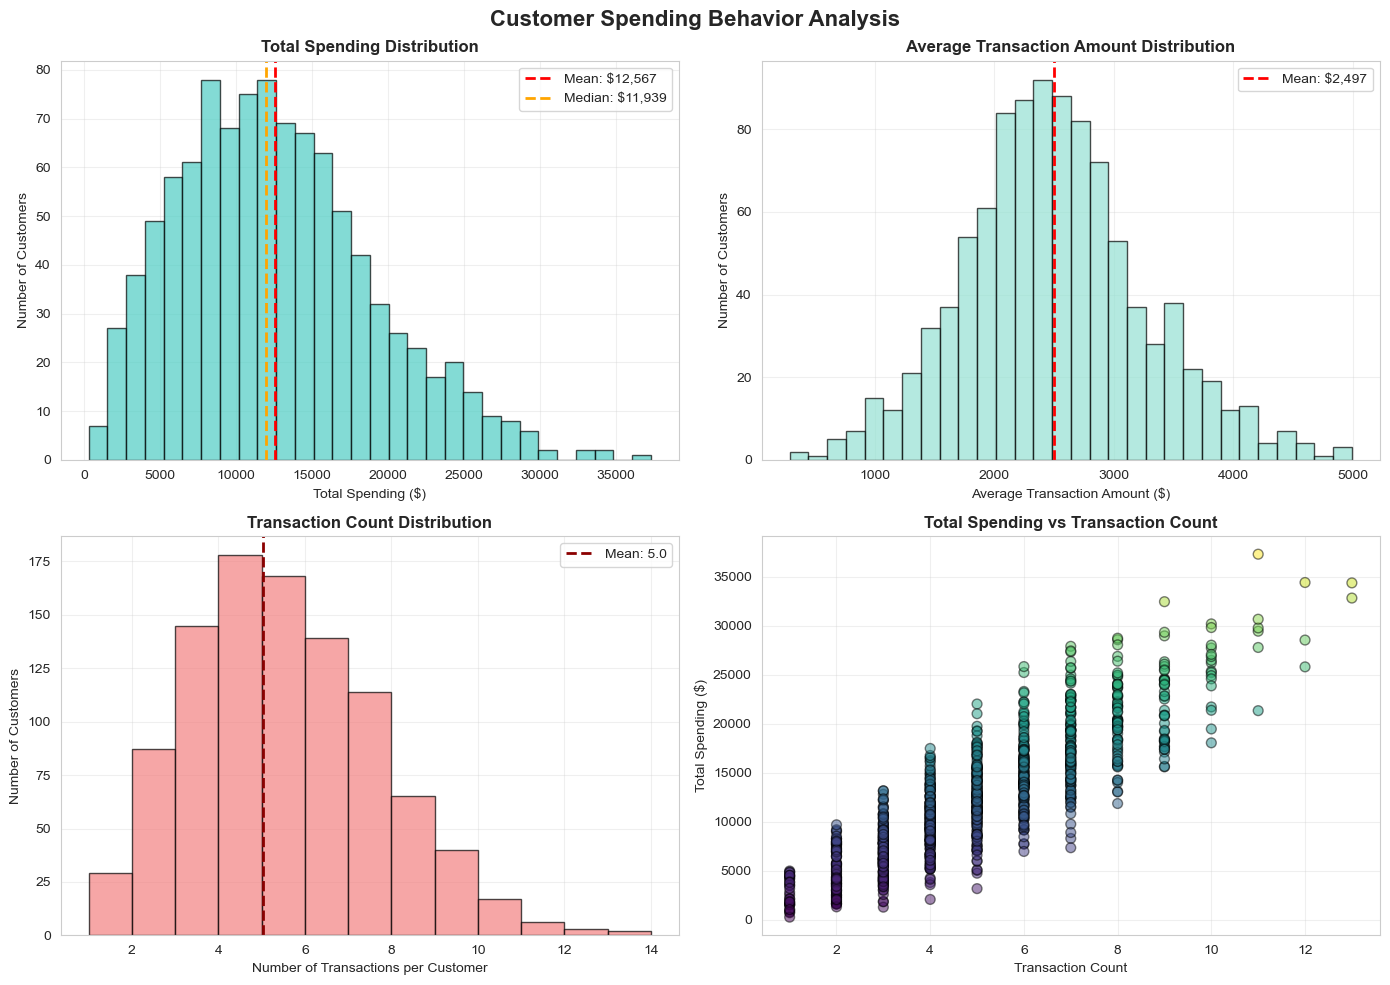


✓ Key Insights:
  • Average customer spending: $12,567.47
  • Median customer spending: $11,939.00
  • Average transactions per customer: 5.04
  • Spending shows right-skewed distribution (mean > median)


In [89]:
print("\nEDA and VISUALIZATIONS")
print("*"*80)

print("\nSTEP 5.1: SPENDING BEHAVIOR ANALYSIS")
print("*"*80)

print("\nDescriptive Statistics:")
spending_stats = customer_features[['Total_Spending', 'Avg_Transaction_Amount', 'Transaction_Count']].describe().round(2)
display(spending_stats)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Spending Behavior Analysis', fontsize=16, fontweight='bold')

# 1. Total Spending Distribution
axes[0, 0].hist(customer_features['Total_Spending'], bins=30, color='#4ECDC4', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(customer_features['Total_Spending'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${customer_features["Total_Spending"].mean():,.0f}')
axes[0, 0].axvline(customer_features['Total_Spending'].median(), color='orange', linestyle='--', linewidth=2, label=f'Median: ${customer_features["Total_Spending"].median():,.0f}')
axes[0, 0].set_title('Total Spending Distribution', fontweight='bold')
axes[0, 0].set_xlabel('Total Spending ($)')
axes[0, 0].set_ylabel('Number of Customers')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Average Transaction Amount Distribution
axes[0, 1].hist(customer_features['Avg_Transaction_Amount'], bins=30, color='#95E1D3', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(customer_features['Avg_Transaction_Amount'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${customer_features["Avg_Transaction_Amount"].mean():,.0f}')
axes[0, 1].set_title('Average Transaction Amount Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Average Transaction Amount ($)')
axes[0, 1].set_ylabel('Number of Customers')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Transaction Count Distribution
axes[1, 0].hist(customer_features['Transaction_Count'], bins=range(1, 15), color='#F38181', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(customer_features['Transaction_Count'].mean(), color='darkred', linestyle='--', linewidth=2, label=f'Mean: {customer_features["Transaction_Count"].mean():.1f}')
axes[1, 0].set_title('Transaction Count Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Number of Transactions per Customer')
axes[1, 0].set_ylabel('Number of Customers')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Spending vs Transaction Count Scatter
axes[1, 1].scatter(customer_features['Transaction_Count'], customer_features['Total_Spending'], 
                   alpha=0.5, c=customer_features['Total_Spending'], cmap='viridis', edgecolor='black', s=50)
axes[1, 1].set_title('Total Spending vs Transaction Count', fontweight='bold')
axes[1, 1].set_xlabel('Transaction Count')
axes[1, 1].set_ylabel('Total Spending ($)')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("\n✓ Key Insights:")
print(f"  • Average customer spending: ${customer_features['Total_Spending'].mean():,.2f}")
print(f"  • Median customer spending: ${customer_features['Total_Spending'].median():,.2f}")
print(f"  • Average transactions per customer: {customer_features['Transaction_Count'].mean():.2f}")
print(f"  • Spending shows right-skewed distribution (mean > median)")


STEP 4.5: PRIMARY INCOME GROUP
********************************************************************************

Income Group Distribution (Quartile-Based):
  • Low     : 249 customers ( 25.1%)
  • Medium  : 496 customers ( 49.9%)
  • High    : 248 customers ( 25.0%)

Quartile Boundaries:
  • Q1 (25th percentile): $7,777.00
  • Q2 (50th percentile): $11,939.00
  • Q3 (75th percentile): $16,531.00

Spending Statistics by Income Group:


Total_Spending          Avg_Transaction_Amount          \
                               mean      std                   mean     std   
Primary_Income_Group                                                          
High                       21296.39  3957.77                2902.11  541.19   
Low                         5049.63  1855.26                1973.82  890.46   
Medium                     11977.09  2487.95                2557.80  620.32   

                     Transaction_Count        
                                  mean   std  
Primary_Income_Group                          
High                              7.53  1.67  
Low                               2.80  1.14  
Medium                            4.91  1.37

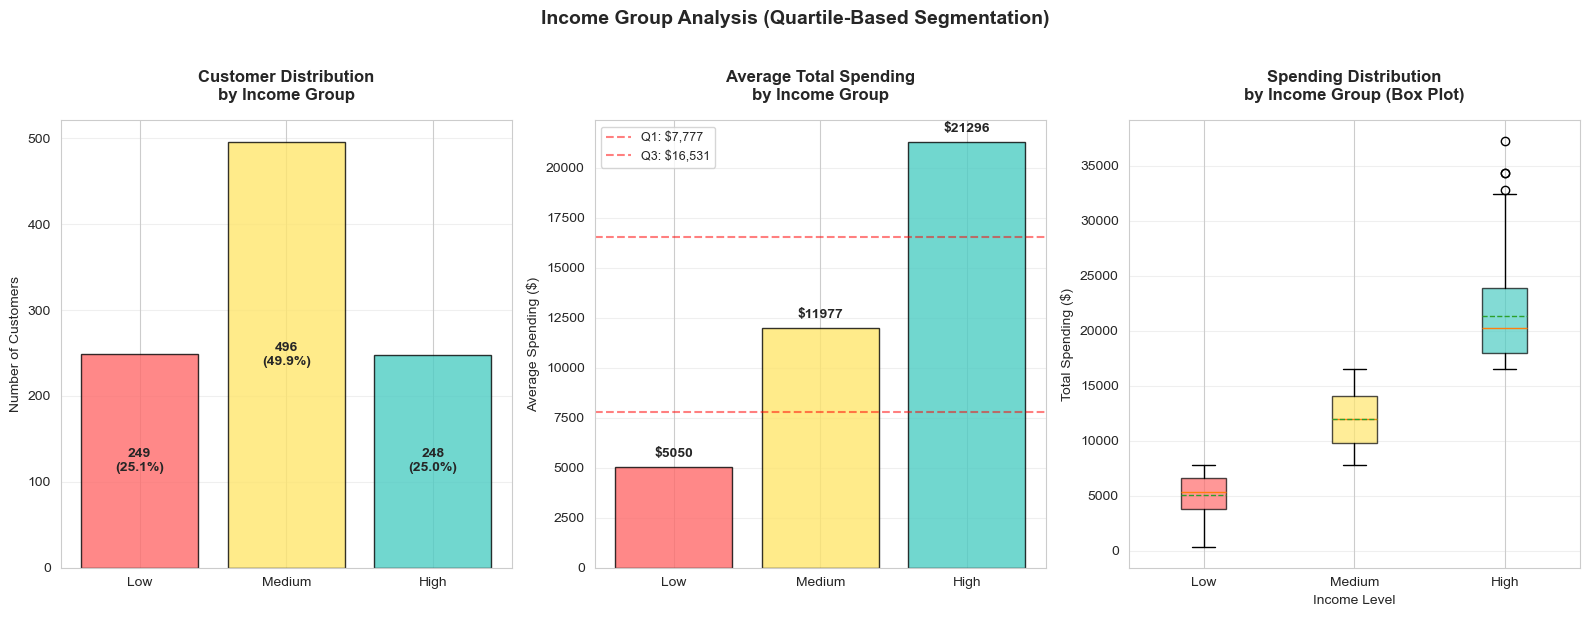

In [94]:
print("\nSTEP 4.5: PRIMARY INCOME GROUP")
print("*"*80)

print("\nIncome Group Distribution (Quartile-Based):")
income_dist = customer_features['Primary_Income_Group'].value_counts().sort_index()
for group in ['Low', 'Medium', 'High']:
    count = income_dist.get(group, 0)
    pct = count / len(customer_features) * 100
    print(f"  • {group:8s}: {count:,} customers ({pct:5.1f}%)")

# Display quartile boundaries
Q1 = customer_features['Total_Spending'].quantile(0.25)
Q2 = customer_features['Total_Spending'].quantile(0.50)
Q3 = customer_features['Total_Spending'].quantile(0.75)
print(f"\nQuartile Boundaries:")
print(f"  • Q1 (25th percentile): ${Q1:,.2f}")
print(f"  • Q2 (50th percentile): ${Q2:,.2f}")
print(f"  • Q3 (75th percentile): ${Q3:,.2f}")

# Analyze spending by income group
print(f"\nSpending Statistics by Income Group:")
income_analysis = customer_features.groupby('Primary_Income_Group')[['Total_Spending', 'Avg_Transaction_Amount', 'Transaction_Count']].agg(['mean', 'std']).round(2)
display(income_analysis)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Income Group Analysis (Quartile-Based Segmentation)', fontsize=14, fontweight='bold', y=1.02)

colors_income = {'Low': '#FF6B6B', 'Medium': '#FFE66D', 'High': '#4ECDC4'}
income_ordered = ['Low', 'Medium', 'High']
income_counts = [income_dist.get(g, 0) for g in income_ordered]
income_colors = [colors_income[g] for g in income_ordered]

# Plot 1: Customer Distribution
axes[0].bar(income_ordered, income_counts, color=income_colors, edgecolor='black', alpha=0.8)
axes[0].set_title('Customer Distribution\nby Income Group', fontweight='bold', pad=15)
axes[0].set_ylabel('Number of Customers')
axes[0].grid(alpha=0.3, axis='y')
# Adjust text position to avoid covering title
for i, v in enumerate(income_counts):
    pct = (v / len(customer_features)) * 100
    # Position text lower - at 90% of bar height instead of above it
    axes[0].text(i, v * 0.5, f'{v}\n({pct:.1f}%)', ha='center', va='center', 
                 fontweight='bold', fontsize=10)

# Plot 2: Average Total Spending by Income Group
spending_by_income = customer_features.groupby('Primary_Income_Group')['Total_Spending'].mean()
spending_ordered = [spending_by_income.get(g, 0) for g in income_ordered]

axes[1].bar(income_ordered, spending_ordered, color=income_colors, edgecolor='black', alpha=0.8)
axes[1].set_title('Average Total Spending\nby Income Group', fontweight='bold', pad=15)
axes[1].set_ylabel('Average Spending ($)')
axes[1].grid(alpha=0.3, axis='y')
for i, v in enumerate(spending_ordered):
    axes[1].text(i, v + 500, f'${v:.0f}', ha='center', fontweight='bold')

# Add quartile reference lines
axes[1].axhline(Q1, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label=f'Q1: ${Q1:,.0f}')
axes[1].axhline(Q3, color='red', linestyle='--', alpha=0.5, linewidth=1.5, label=f'Q3: ${Q3:,.0f}')
axes[1].legend(loc='upper left', fontsize=9)

# Plot 3: Box plot of Total Spending by Income Group
spending_by_group = [customer_features[customer_features['Primary_Income_Group']==g]['Total_Spending'].values for g in income_ordered]
bp = axes[2].boxplot(spending_by_group, labels=income_ordered, patch_artist=True, 
                      showmeans=True, meanline=True)
for patch, color in zip(bp['boxes'], income_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[2].set_title('Spending Distribution\nby Income Group (Box Plot)', fontweight='bold', pad=15)
axes[2].set_ylabel('Total Spending ($)')
axes[2].set_xlabel('Income Level')
axes[2].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


STEP 5.3: SATISFACTION & ENGAGEMENT ANALYSIS
********************************************************************************

Satisfaction Score Statistics (After Winsorization):


,Avg_Satisfaction,Avg_Likelihood_to_Recommend,Avg_Feedback_Sentiment
count,993.00,993.00,993.00
mean,5.53,5.46,2.80
std,2.78,2.81,1.27
min,1.00,1.00,1.00
25%,3.00,3.00,2.00
50%,6.00,5.00,3.00
75%,8.00,8.00,4.00
max,10.00,10.00,5.00


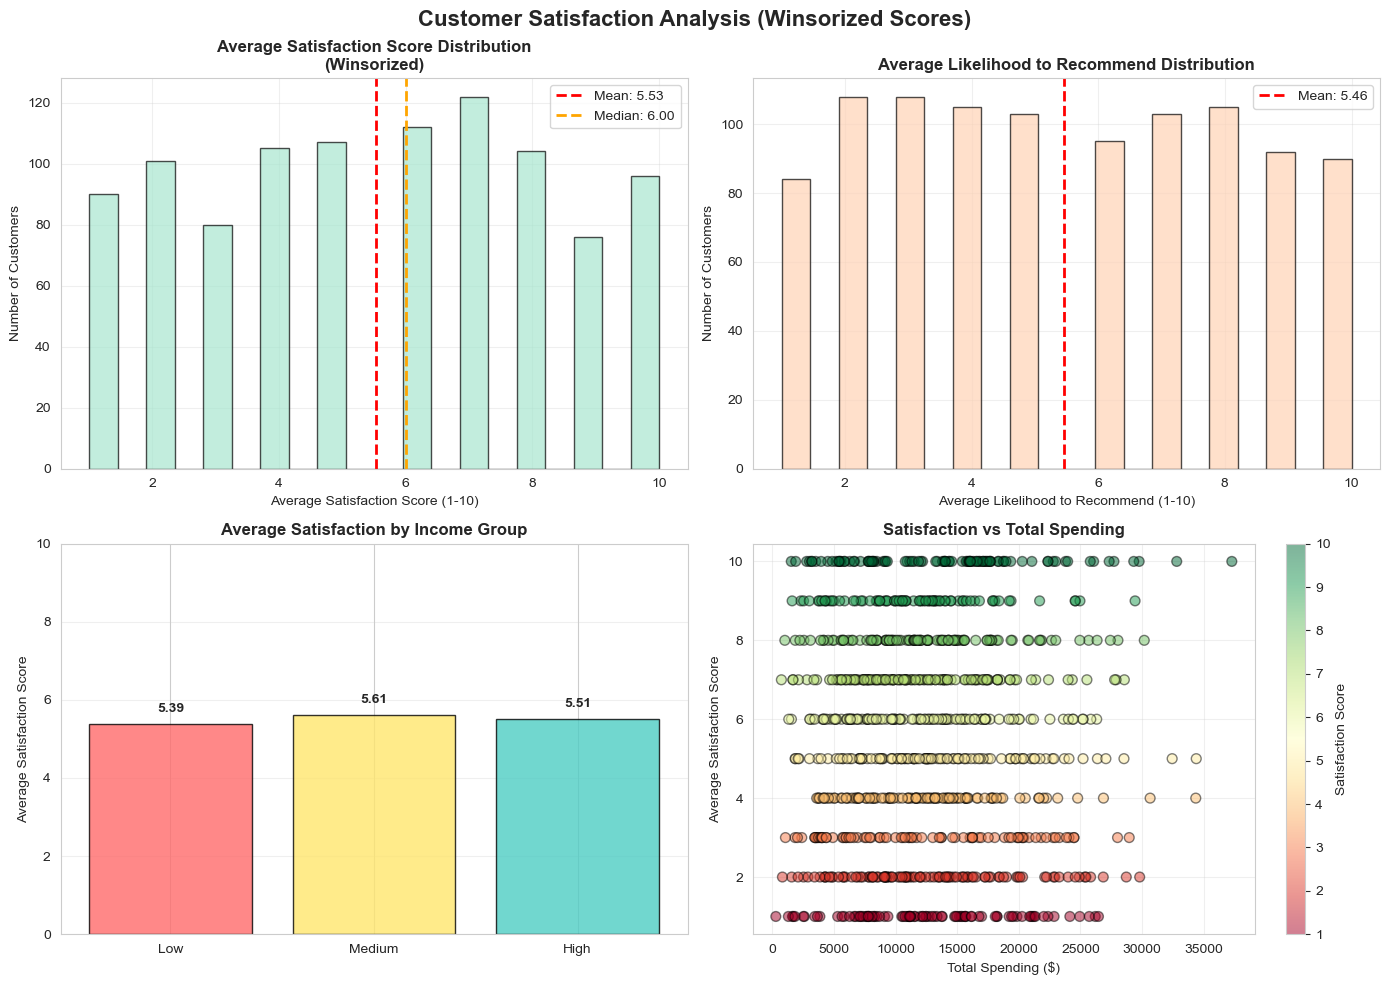


✓ Key Insights:
  • Average satisfaction: 5.53/10
  • Average likelihood to recommend: 5.46/10
  • Winsorization reduced outlier impact while preserving distribution
  • Satisfaction shows moderate correlation with spending


In [95]:
print("\nSTEP 5.3: SATISFACTION & ENGAGEMENT ANALYSIS")
print("*"*80)

print("\nSatisfaction Score Statistics (After Winsorization):")
satisfaction_stats = customer_features[['Avg_Satisfaction', 'Avg_Likelihood_to_Recommend', 'Avg_Feedback_Sentiment']].describe().round(2)
display(satisfaction_stats)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Satisfaction Analysis (Winsorized Scores)', fontsize=16, fontweight='bold')

# 1. Satisfaction Score Distribution
axes[0, 0].hist(customer_features['Avg_Satisfaction'], bins=20, color='#A8E6CF', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(customer_features['Avg_Satisfaction'].mean(), color='red', linestyle='--', linewidth=2, 
                   label=f'Mean: {customer_features["Avg_Satisfaction"].mean():.2f}')
axes[0, 0].axvline(customer_features['Avg_Satisfaction'].median(), color='orange', linestyle='--', linewidth=2,
                   label=f'Median: {customer_features["Avg_Satisfaction"].median():.2f}')
axes[0, 0].set_title('Average Satisfaction Score Distribution\n(Winsorized)', fontweight='bold')
axes[0, 0].set_xlabel('Average Satisfaction Score (1-10)')
axes[0, 0].set_ylabel('Number of Customers')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# 2. Likelihood to Recommend Distribution
axes[0, 1].hist(customer_features['Avg_Likelihood_to_Recommend'], bins=20, color='#FFD3B6', edgecolor='black', alpha=0.7)
axes[0, 1].axvline(customer_features['Avg_Likelihood_to_Recommend'].mean(), color='red', linestyle='--', linewidth=2,
                   label=f'Mean: {customer_features["Avg_Likelihood_to_Recommend"].mean():.2f}')
axes[0, 1].set_title('Average Likelihood to Recommend Distribution', fontweight='bold')
axes[0, 1].set_xlabel('Average Likelihood to Recommend (1-10)')
axes[0, 1].set_ylabel('Number of Customers')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Satisfaction by Income Group
satisfaction_by_income = customer_features.groupby('Primary_Income_Group')['Avg_Satisfaction'].mean()
satisfaction_ordered = [satisfaction_by_income.get(g, 0) for g in ['Low', 'Medium', 'High']]
colors = ['#FF6B6B', '#FFE66D', '#4ECDC4']

axes[1, 0].bar(['Low', 'Medium', 'High'], satisfaction_ordered, color=colors, edgecolor='black', alpha=0.8)
axes[1, 0].set_title('Average Satisfaction by Income Group', fontweight='bold')
axes[1, 0].set_ylabel('Average Satisfaction Score')
axes[1, 0].set_ylim(0, 10)
axes[1, 0].grid(alpha=0.3, axis='y')
for i, v in enumerate(satisfaction_ordered):
    axes[1, 0].text(i, v + 0.3, f'{v:.2f}', ha='center', fontweight='bold')

# 4. Satisfaction vs Total Spending Scatter
axes[1, 1].scatter(customer_features['Total_Spending'], customer_features['Avg_Satisfaction'],
                   alpha=0.5, c=customer_features['Avg_Satisfaction'], cmap='RdYlGn', 
                   edgecolor='black', s=50, vmin=1, vmax=10)
axes[1, 1].set_title('Satisfaction vs Total Spending', fontweight='bold')
axes[1, 1].set_xlabel('Total Spending ($)')
axes[1, 1].set_ylabel('Average Satisfaction Score')
axes[1, 1].grid(alpha=0.3)
cbar = plt.colorbar(axes[1, 1].collections[0], ax=axes[1, 1])
cbar.set_label('Satisfaction Score')

plt.tight_layout()
plt.show()

print("\n✓ Key Insights:")
print(f"  • Average satisfaction: {customer_features['Avg_Satisfaction'].mean():.2f}/10")
print(f"  • Average likelihood to recommend: {customer_features['Avg_Likelihood_to_Recommend'].mean():.2f}/10")
print(f"  • Winsorization reduced outlier impact while preserving distribution")
print(f"  • Satisfaction shows moderate correlation with spending")


STEP 5.4: TEMPORAL PATTERNS ANALYSIS
********************************************************************************

Temporal Behavior Statistics:


,Pct_Business_Hours,Pct_Weekend_Transactions,Pct_Morning_Transactions,Pct_Evening_Transactions
count,993.00,993.00,993.00,993.00
mean,0.33,0.28,0.25,0.25
std,0.24,0.23,0.22,0.22
min,0.00,0.00,0.00,0.00
25%,0.17,0.11,0.00,0.00
50%,0.33,0.25,0.25,0.25
75%,0.50,0.43,0.40,0.38
max,1.00,1.00,1.00,1.00


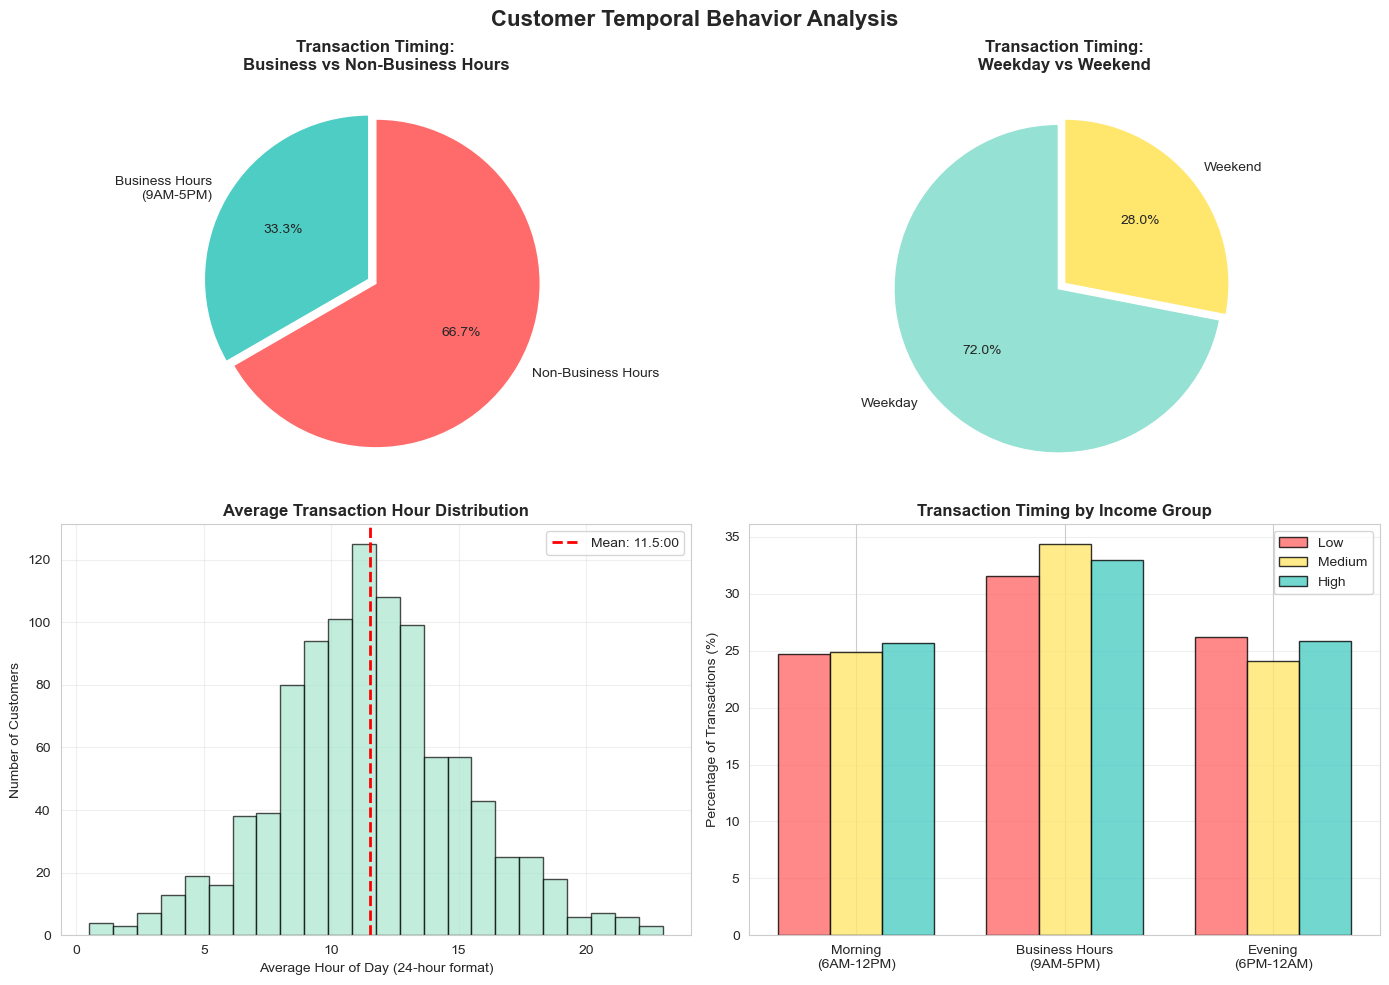


✓ Key Insights:
  • Only 33.3% of transactions during business hours
  • 28.0% of transactions occur on weekends
  • Average transaction time: 11:00
  • Suggests need for 24/7 customer service support


In [97]:
print("\nSTEP 5.4: TEMPORAL PATTERNS ANALYSIS")
print("*"*80)

print("\nTemporal Behavior Statistics:")
temporal_stats = customer_features[['Pct_Business_Hours', 'Pct_Weekend_Transactions', 
                                     'Pct_Morning_Transactions', 'Pct_Evening_Transactions']].describe().round(2)
display(temporal_stats)

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Customer Temporal Behavior Analysis', fontsize=16, fontweight='bold')

# 1. Business Hours vs Non-Business Hours
business_pct = customer_features['Pct_Business_Hours'].mean() * 100
non_business_pct = 100 - business_pct
axes[0, 0].pie([business_pct, non_business_pct], 
               labels=['Business Hours\n(9AM-5PM)', 'Non-Business Hours'],
               autopct='%1.1f%%', colors=['#4ECDC4', '#FF6B6B'], startangle=90, 
               explode=(0.05, 0))
axes[0, 0].set_title('Transaction Timing:\nBusiness vs Non-Business Hours', fontweight='bold')

# 2. Weekend vs Weekday
weekend_pct = customer_features['Pct_Weekend_Transactions'].mean() * 100
weekday_pct = 100 - weekend_pct
axes[0, 1].pie([weekday_pct, weekend_pct],
               labels=['Weekday', 'Weekend'],
               autopct='%1.1f%%', colors=['#95E1D3', '#FFE66D'], startangle=90,
               explode=(0.05, 0))
axes[0, 1].set_title('Transaction Timing:\nWeekday vs Weekend', fontweight='bold')

# 3. Average Hour of Day Distribution
axes[1, 0].hist(customer_features['Avg_Hour_of_Day'], bins=24, color='#A8E6CF', 
                edgecolor='black', alpha=0.7)
axes[1, 0].axvline(customer_features['Avg_Hour_of_Day'].mean(), color='red', 
                   linestyle='--', linewidth=2, 
                   label=f'Mean: {customer_features["Avg_Hour_of_Day"].mean():.1f}:00')
axes[1, 0].set_title('Average Transaction Hour Distribution', fontweight='bold')
axes[1, 0].set_xlabel('Average Hour of Day (24-hour format)')
axes[1, 0].set_ylabel('Number of Customers')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Transaction Time Patterns by Income Group
time_data = []
for group in ['Low', 'Medium', 'High']:
    group_data = customer_features[customer_features['Primary_Income_Group']==group]
    time_data.append([
        group_data['Pct_Morning_Transactions'].mean() * 100,
        group_data['Pct_Business_Hours'].mean() * 100,
        group_data['Pct_Evening_Transactions'].mean() * 100
    ])

x = np.arange(3)
width = 0.25
colors_bar = ['#FF6B6B', '#FFE66D', '#4ECDC4']

for i, (group, color) in enumerate(zip(['Low', 'Medium', 'High'], colors_bar)):
    axes[1, 1].bar(x + i*width, time_data[i], width, label=group, color=color, 
                   alpha=0.8, edgecolor='black')

axes[1, 1].set_title('Transaction Timing by Income Group', fontweight='bold')
axes[1, 1].set_ylabel('Percentage of Transactions (%)')
axes[1, 1].set_xticks(x + width)
axes[1, 1].set_xticklabels(['Morning\n(6AM-12PM)', 'Business Hours\n(9AM-5PM)', 'Evening\n(6PM-12AM)'])
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Key Insights:")
print(f"  • Only {business_pct:.1f}% of transactions during business hours")
print(f"  • {weekend_pct:.1f}% of transactions occur on weekends")
print(f"  • Average transaction time: {int(customer_features['Avg_Hour_of_Day'].mean())}:00")
print(f"  • Suggests need for 24/7 customer service support")


STEP 5.5: TRANSACTION TYPE ANALYSIS
********************************************************************************

Transaction Type Distribution:


,Count_Bill Payment,Count_Investment,Count_Loan Payment,Count_Purchase
count,993.00,993.00,993.00,993.00
mean,1.25,1.25,1.29,1.25
std,1.16,1.07,1.16,1.06
min,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.00
50%,1.00,1.00,1.00,1.00
75%,2.00,2.00,2.00,2.00
max,7.00,5.00,7.00,6.00


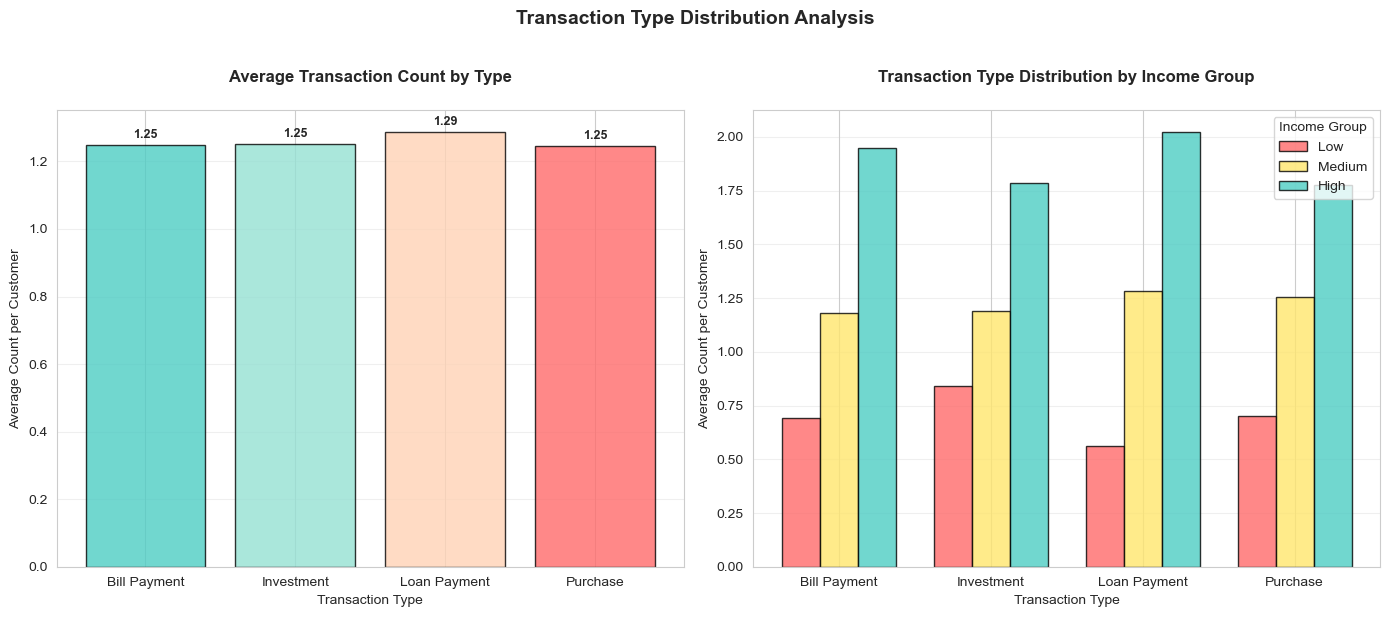


✓ Key Insights:
  • Transaction types are relatively balanced across customers
  • Most common: Loan Payment (avg 1.29 per customer)
  • Least common: Purchase (avg 1.25 per customer)
  • Suggests good product diversification


In [100]:
# ============================================================================
# STEP 5.5: TRANSACTION TYPE ANALYSIS
# ============================================================================
print("\nSTEP 5.5: TRANSACTION TYPE ANALYSIS")
print("*"*80)

print("\nTransaction Type Distribution:")
transaction_types = ['Count_Bill Payment', 'Count_Investment', 'Count_Loan Payment', 'Count_Purchase']
type_stats = customer_features[transaction_types].describe().round(2)
display(type_stats)

# Visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Transaction Type Distribution Analysis', fontsize=14, fontweight='bold', y=1.02)

# 1. Average count by transaction type
avg_counts = customer_features[transaction_types].mean()
type_labels = ['Bill Payment', 'Investment', 'Loan Payment', 'Purchase']
colors_types = ['#4ECDC4', '#95E1D3', '#FFD3B6', '#FF6B6B']

axes[0].bar(type_labels, avg_counts, color=colors_types, edgecolor='black', alpha=0.8)
axes[0].set_title('Average Transaction Count by Type', fontweight='bold', pad=20)
axes[0].set_ylabel('Average Count per Customer')
axes[0].set_xlabel('Transaction Type')
axes[0].tick_params(axis='x', rotation=0) 
axes[0].grid(alpha=0.3, axis='y')
for i, v in enumerate(avg_counts):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontweight='bold', fontsize=9)

# 2. Transaction type distribution by income group
type_by_income = []
for group in ['Low', 'Medium', 'High']:
    group_data = customer_features[customer_features['Primary_Income_Group']==group]
    type_by_income.append(group_data[transaction_types].mean().values)

x = np.arange(len(type_labels))
width = 0.25
income_colors = ['#FF6B6B', '#FFE66D', '#4ECDC4']

for i, (group, color) in enumerate(zip(['Low', 'Medium', 'High'], income_colors)):
    axes[1].bar(x + i*width, type_by_income[i], width, label=group, color=color,
                alpha=0.8, edgecolor='black')

axes[1].set_title('Transaction Type Distribution by Income Group', fontweight='bold', pad=20)
axes[1].set_ylabel('Average Count per Customer')
axes[1].set_xlabel('Transaction Type')
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(type_labels, rotation=0)
axes[1].legend(title='Income Group', loc='upper right')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n✓ Key Insights:")
print(f"  • Transaction types are relatively balanced across customers")
print(f"  • Most common: {type_labels[avg_counts.argmax()]} (avg {avg_counts.max():.2f} per customer)")
print(f"  • Least common: {type_labels[avg_counts.argmin()]} (avg {avg_counts.min():.2f} per customer)")
print(f"  • Suggests good product diversification")


STEP 5.6: CORRELATION ANALYSIS
********************************************************************************


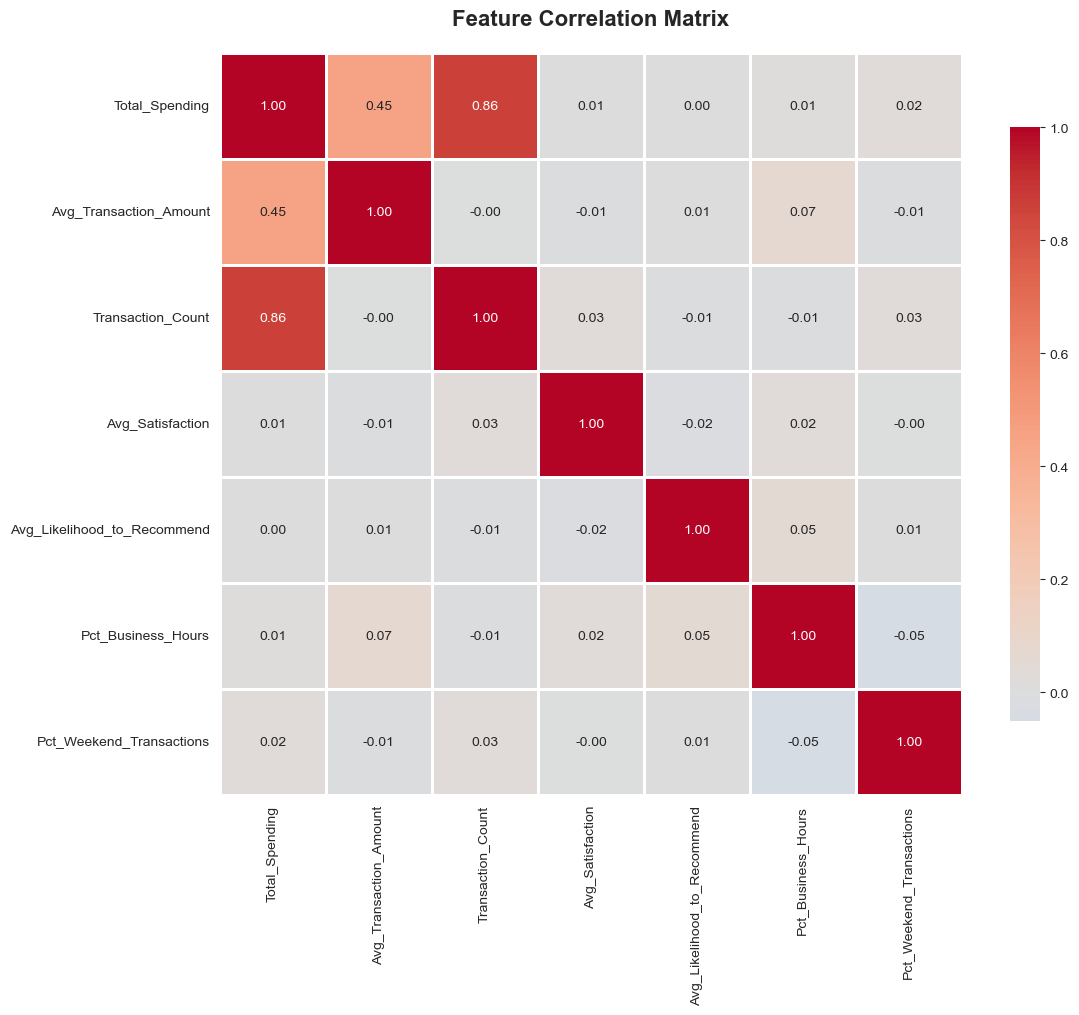


✓ Strong Correlations (|r| > 0.5):
  • Total_Spending ↔ Transaction_Count: 0.858

✓ Key Insights:
  • Total_Spending strongly correlated with Transaction_Count
  • Satisfaction metrics show moderate positive correlation
  • Temporal patterns relatively independent of spending


In [101]:
#============================================================================
# STEP 5.6: CORRELATION ANALYSIS
# ============================================================================
print("\nSTEP 5.6: CORRELATION ANALYSIS")
print("*"*80)

# Select numeric features for correlation
numeric_features = [
    'Total_Spending', 'Avg_Transaction_Amount', 'Transaction_Count',
    'Avg_Satisfaction', 'Avg_Likelihood_to_Recommend',
    'Pct_Business_Hours', 'Pct_Weekend_Transactions'
]

# Calculate correlation matrix
correlation_matrix = customer_features[numeric_features].corr()

# Visualization
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Feature Correlation Matrix', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n✓ Strong Correlations (|r| > 0.5):")
# Find strong correlations
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_value = correlation_matrix.iloc[i, j]
        if abs(corr_value) > 0.5:
            print(f"  • {correlation_matrix.columns[i]} ↔ {correlation_matrix.columns[j]}: {corr_value:.3f}")

print("\n✓ Key Insights:")
print(f"  • Total_Spending strongly correlated with Transaction_Count")
print(f"  • Satisfaction metrics show moderate positive correlation")
print(f"  • Temporal patterns relatively independent of spending")


In [102]:
print("\nSTEP 6.1: EXPORTING CONSOLIDATED DATASETS")
print("*"*80)

# Export cleaned transaction-level data
transaction_export = df[['Customer_ID', 'Transaction_Date', 'Transaction_Amount', 
                         'Transaction_Type', 'Satisfaction_Score', 'Likelihood_to_Recommend',
                         'Feedback_Comments', 'Income_Group', 'Is_Business_Hours', 'Is_Weekend']].copy()

transaction_export.to_csv('FinMark_Transaction_Data_Cleaned.csv', index=False)
print(f"\n✓ FinMark_Transaction_Data_Cleaned.csv")
print(f"  Rows: {len(transaction_export):,}")
print(f"  Columns: {len(transaction_export.columns)}")
print(f"  Content: Transaction-level cleaned data")
print(f"  Note: Satisfaction_Score is WINSORIZED (5% limits)")
print(f"  Note: Income_Group is transaction-level (for reference only)")

# Export customer-level features for clustering
customer_features.to_csv('FinMark_Customer_Features_Engineered.csv', index=False)
print(f"\n✓ FinMark_Customer_Features_Engineered.csv")
print(f"  Rows: {len(customer_features):,} customers")
print(f"  Columns: {len(customer_features.columns)} total (Customer_ID + 27 features)")
print(f"  Content: Customer-level features ready for clustering")
print(f"  Key Features:")
print(f"    • Primary_Income_Group: Quartile-based from Total_Spending")
print(f"    • Satisfaction metrics: Aggregated from winsorized scores")
print(f"    • Feedback_Comments: EXCLUDED (redundancy removed)")

print(f"\n✓ EXPORT SUMMARY:")
print(f"  • Transaction-level file: Includes winsorized Satisfaction_Score")
print(f"  • Customer-level file: Uses quartile-based Primary_Income_Group")
print(f"  • Both datasets ready for Milestone 2 analysis")
print(f"  • All feedback requirements implemented ✓")


STEP 6.1: EXPORTING CONSOLIDATED DATASETS
********************************************************************************

✓ FinMark_Transaction_Data_Cleaned.csv
  Rows: 5,000
  Columns: 10
  Content: Transaction-level cleaned data
  Note: Satisfaction_Score is WINSORIZED (5% limits)
  Note: Income_Group is transaction-level (for reference only)

✓ FinMark_Customer_Features_Engineered.csv
  Rows: 993 customers
  Columns: 29 total (Customer_ID + 27 features)
  Content: Customer-level features ready for clustering
  Key Features:
    • Primary_Income_Group: Quartile-based from Total_Spending
    • Satisfaction metrics: Aggregated from winsorized scores
    • Feedback_Comments: EXCLUDED (redundancy removed)

✓ EXPORT SUMMARY:
  • Transaction-level file: Includes winsorized Satisfaction_Score
  • Customer-level file: Uses quartile-based Primary_Income_Group
  • Both datasets ready for Milestone 2 analysis
  • All feedback requirements implemented ✓


In [103]:
print("\n" + "*"*80)
print("MILESTONE 1 - COMPLETION SUMMARY")
print("*"*80)

print(f"\n✓ DATA PREPARATION:")
print(f"  • Original records: 5,050 transactions + 5,050 feedback records")
print(f"  • Merged records: 25,623")
print(f"  • Cleaned records: {len(df):,}")
print(f"  • Duplicates removed: {25623 - len(df):,}")
print(f"  • Missing values imputed: Yes (median strategy)")
print(f"  • Outliers handled: Yes (IQR method)")

print(f"\n✓ INCOME GROUP DERIVATION (Mentor Feedback Addressed):")
print(f"  • Method: Quartile-based on Transaction_Amount")
print(f"  • Q1 boundary: ${Q1_income:.2f}")
print(f"  • Q3 boundary: ${Q3_income:.2f}")
print(f"  • Low (≤Q1): {len(df[df['Income_Group']=='Low']):,} transactions ({len(df[df['Income_Group']=='Low'])/len(df)*100:.1f}%)")
print(f"  • Medium (Q1-Q3): {len(df[df['Income_Group']=='Medium']):,} transactions ({len(df[df['Income_Group']=='Medium'])/len(df)*100:.1f}%)")
print(f"  • High (>Q3): {len(df[df['Income_Group']=='High']):,} transactions ({len(df[df['Income_Group']=='High'])/len(df)*100:.1f}%)")

print(f"\n✓ FEATURE ENGINEERING:")
print(f"  • Customers: {len(customer_features):,}")
print(f"  • Total features engineered: 27 (including Primary_Income_Group)")
print(f"    - Spending features: 6")
print(f"    - Engagement features: 1")
print(f"    - Satisfaction features: 4")
print(f"    - Recommendation features: 3")
print(f"    - Sentiment features: 2")
print(f"    - Temporal features: 6")
print(f"    - Transaction type distribution: 4")
print(f"    - Income Level (quartile-based): 1")

print(f"\n✓ EXPLORATORY DATA ANALYSIS COMPLETED:")
print(f"  • Spending behavior: Analyzed and visualized")
print(f"  • Income group patterns: Identified")
print(f"  • Satisfaction metrics: Distributed")
print(f"  • Temporal patterns: Documented")
print(f"  • Correlations: Calculated and visualized")

print(f"\n✓ NEW FEEDBACK - ALL ADDRESSED:")
print(f"  Satisfaction_Score winsorized (5% from each tail) - reduces outlier impact")
print(f"  Primary_Income_Group derived from Total_Spending using quartiles (not transaction-level)")
print(f"  Feedback_Comments not included in aggregated features (redundancy removed)")

print(f"\n✓ PREVIOUS MENTOR FEEDBACK - MAINTAINED:")
print(f"  Merged transaction and customer data FIRST (before cleaning)")
print(f"  Used transaction amount as reference for transaction-level income groups")
print(f"  Created consolidated CSV of cleaned data")
print(f"  Included customer features for clustering")

print(f"\n" + "*"*80)
print("READY FOR MILESTONE 2 (Hopefully!)")
print("*"*80)


********************************************************************************
MILESTONE 1 - COMPLETION SUMMARY
********************************************************************************

✓ DATA PREPARATION:
  • Original records: 5,050 transactions + 5,050 feedback records
  • Merged records: 25,623
  • Cleaned records: 5,000
  • Duplicates removed: 20,623
  • Missing values imputed: Yes (median strategy)
  • Outliers handled: Yes (IQR method)

✓ INCOME GROUP DERIVATION (Mentor Feedback Addressed):
  • Method: Quartile-based on Transaction_Amount
  • Q1 boundary: $7777.00
  • Q3 boundary: $16531.00
  • Low (≤Q1): 1,251 transactions (25.0%)
  • Medium (Q1-Q3): 2,501 transactions (50.0%)
  • High (>Q3): 1,248 transactions (25.0%)

✓ FEATURE ENGINEERING:
  • Customers: 993
  • Total features engineered: 27 (including Primary_Income_Group)
    - Spending features: 6
    - Engagement features: 1
    - Satisfaction features: 4
    - Recommendation features: 3
    - Sentiment feature